## Mini Project: Self-supervised denoising of Cryo-EM images with DeepInverse

You will access a dataset of 5 real 3838 x 3710 cryo electron microscopy images from the [Topaz dataset](https://www.nature.com/articles/s41467-020-18952-1) which
are corrupted by real measurement noise and have very low signal-to-noise ratio.
The noise distribution is unknown (although approximately Poisson-Gaussian).

The **goal** of this mini project is to train a network using fully self-supervised losses which only require noisy images and no ground-truth references to denoise these images.

**DeepInverse Documentation**: https://deepinv.github.io/

**Tip**: you can check out one of the [self-supervised training examples](https://deepinv.github.io/deepinv/auto_examples/self-supervised-learning/index.html) in the documentation if you get stuck!

### Step 1: Download the library and the cryo-EM dataset

We start by downloading the latest version of deepinverse, and plot a noisy image. We will load two versions of the dataset: the first one with full-sized images for testing (3838 x 3710), and the second one with (128 x 128) patches
for efficient training. This step is already finished, so you can start directly with step 2.

In [ ]:
%%capture
pip install git+https://github.com/deepinv/deepinv.git#egg=deepinv

In [ ]:
import torch
import deepinv as dinv
from torchvision import transforms
import matplotlib.pyplot as plt

We can download the dataset from a hugging face repo

In [ ]:
  # download dataset
  from huggingface_hub import hf_hub_download
  path = hf_hub_download(repo_id="jtachella/finetuning", repo_type="dataset", filename="cryo_em/dinv_dataset0.h5")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


dinv_dataset0.h5:   0%|          | 0.00/570M [00:00<?, ?B/s]

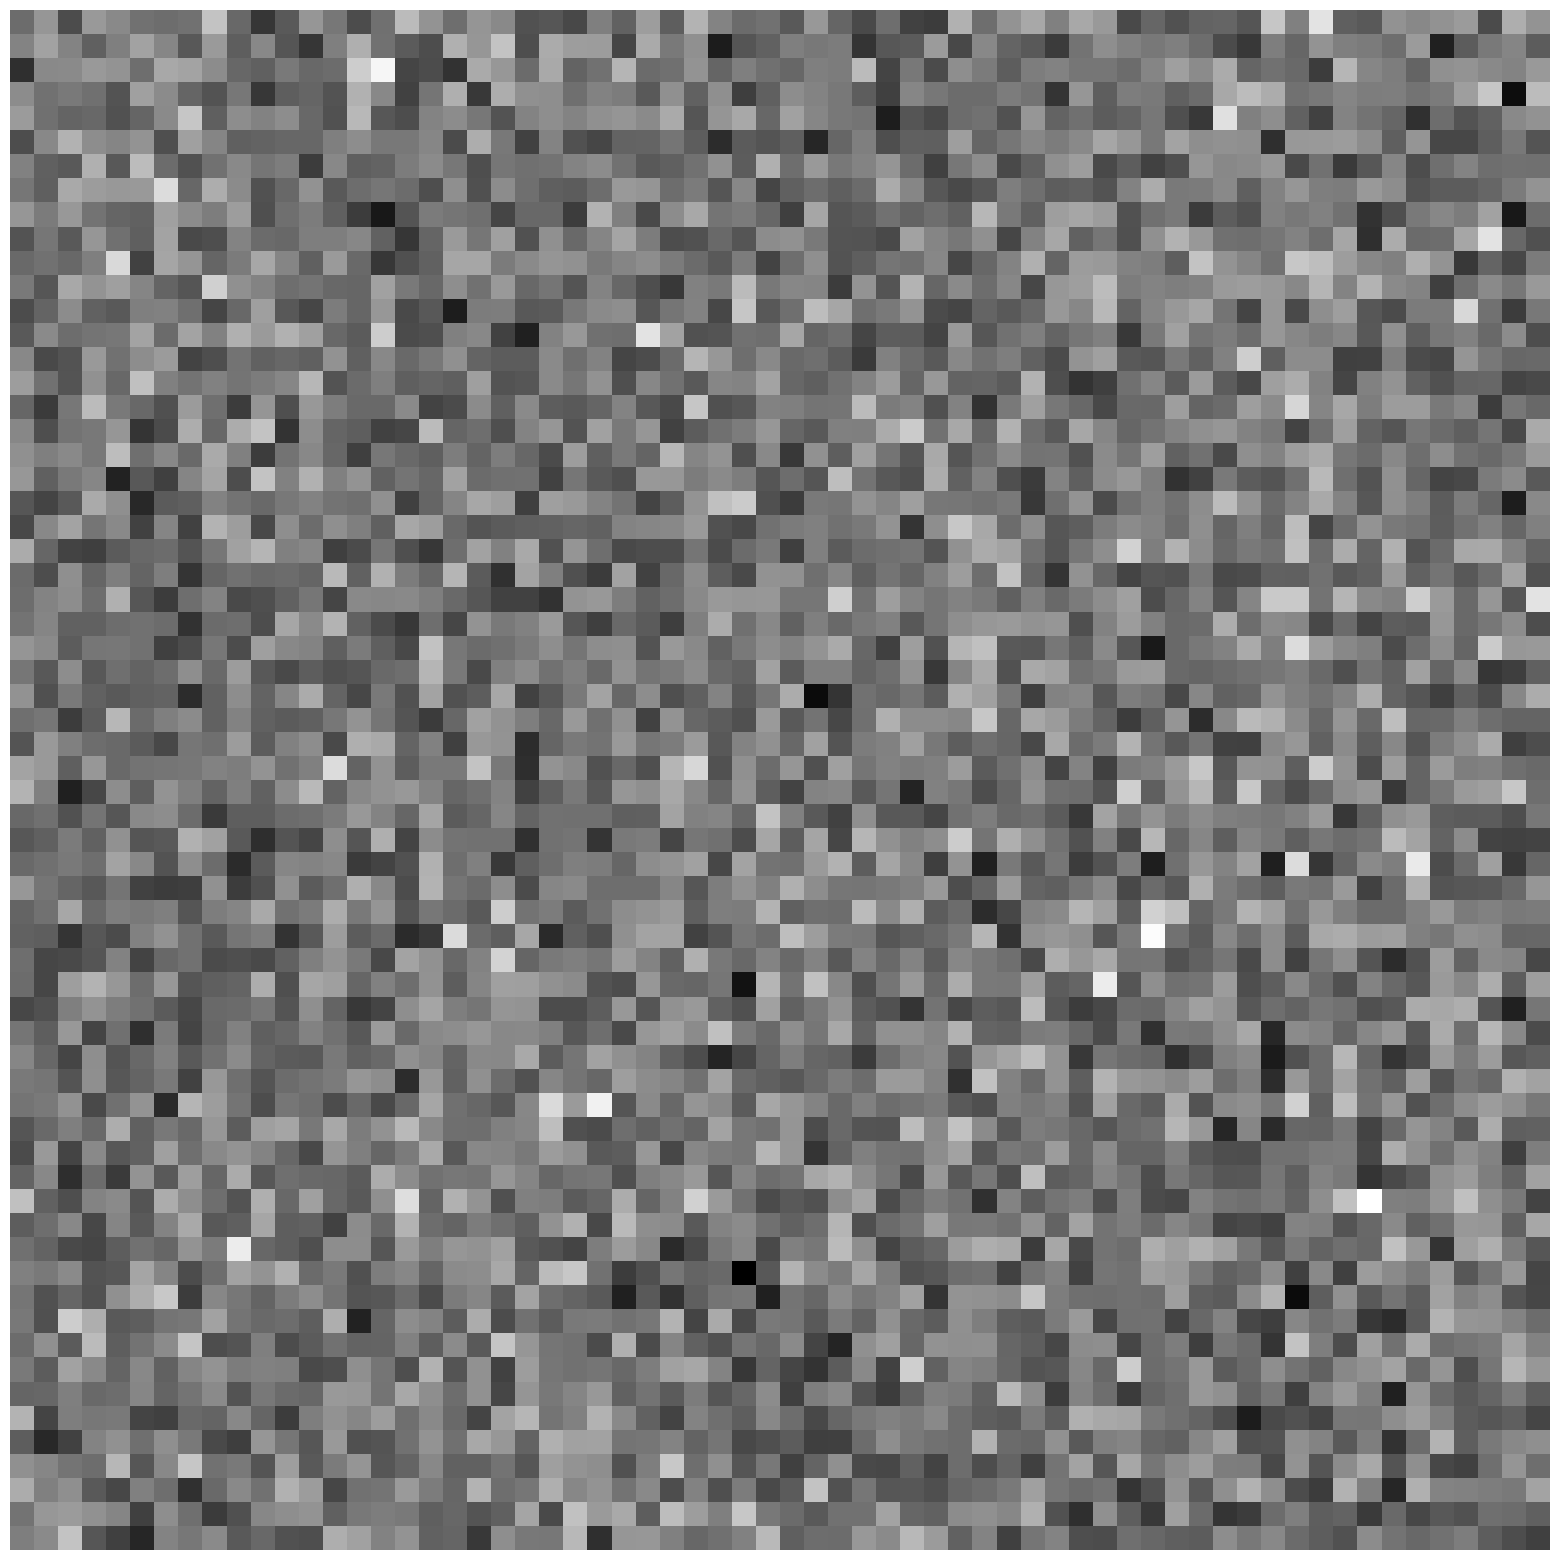

Selected GPU 0 with 15092 MiB free memory 


In [ ]:
patch_size = 64
test_dataset = dinv.datasets.HDF5Dataset(path=path, transform=transforms.RandomCrop(patch_size))

y, _ = test_dataset[0]
dinv.utils.plot(y, figsize=(20,20))

device = dinv.utils.get_freer_gpu()

Plot the histograms of observed values to make sure that everything is well normalized

test shape torch.Size([1, 64, 64]) max value  tensor(3.9118) min value tensor(-3.4516)


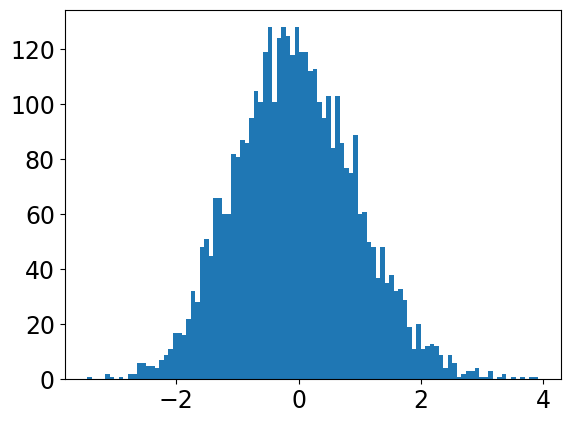

In [ ]:
plt.hist(y.flatten().numpy(), bins=100)
print('test shape', y.shape, 'max value ', y.max(), 'min value', y.min())

This step preprocess regenerates the train dataset into small patches to avoid memory issues

In [ ]:
path = dinv.datasets.generate_dataset(train_dataset=dinv.datasets.HDF5Dataset(path=path, transform=transforms.RandomCrop(patch_size)),
                               physics=dinv.physics.Denoising(dinv.physics.GaussianNoise(0.)),
                               train_datapoints=2000, # number of random patches
                               save_dir='.')

train_dataset = dinv.datasets.HDF5Dataset(path=path)

Dataset has been saved at ./dinv_dataset0.h5


### Step 2: Set up dataloaders for training


### Step 3: Choose the denoiser network architecture and self-supervised loss

Here you should pick your denoiser network from the [list of models](https://deepinv.github.io/deepinv/user_guide/reconstruction/denoisers.html#deep-denoisers) and a self-supervised loss from the [list of losses](https://deepinv.github.io/deepinv/user_guide/training/loss.html#self-supervised-learning).


**Tip 1**: If you choose a convolutional network, you should be able to train on small patches (e.g., 128x128) and then test on the full high-resolution images.

**Tip 2**: You can pick a pretrained denoiser network (eg [DRUNet](https://deepinv.github.io/deepinv/api/stubs/deepinv.models.DRUNet.html#deepinv.models.DRUNet)), and finetune it on the Cryo-EM data. Starting from a pretrained model generally decreases the training time, and often improves results, but it is not mandatory!

**Tip 3**: You should choose a self-supervised loss that is well suited for the problem:
- If we assume that the noise distribution is unknown but separable across pixels, we can use splitting losses such as a [splitting loss](https://deepinv.github.io/deepinv/api/stubs/deepinv.loss.SplittingLoss.html) or [the Neighbor2Neighbor loss](https://deepinv.github.io/deepinv/api/stubs/deepinv.loss.Neighbor2Neighbor.html).
- If we assume that the noise is Poisson-Gaussian but with unknown noise levels, we can use the [SURE Poisson-Gaussian loss](https://deepinv.github.io/deepinv/api/stubs/deepinv.loss.SurePGLoss.html), with the `unsure=True` flag, which automatically estimates the noise levels.
- If you think that you have a good idea of the noise distribution and noise levels, maybe you can try [SURE](https://deepinv.github.io/deepinv/api/stubs/deepinv.loss.SureGaussianLoss.html#deepinv.loss.SureGaussianLoss) or [Recorrupted2Recorrupted](https://deepinv.github.io/deepinv/api/stubs/deepinv.loss.R2RLoss.html).

Are you interested in knowing more behind these losses? you can check out [this YouTube tutorial](https://www.youtube.com/watch?v=dxgvrooTZqQ&ab_channel=Juli%C3%A1nTachella) on self-supervised learning.


In [ ]:
# TODO

### Step 4: Train!

Here you should create a [Trainer](https://deepinv.github.io/deepinv/api/stubs/deepinv.Trainer.html) object setting up the model, training/eval dataloders, losses, optimizers, epochs, etc.
After setting up the trainer, you can simply to `trainer.train()` to start training.

**Tip 1**: You can create a validation set (with one cryo image that you set apart from the train dataset) and pass a `eval_dataloader` to the trainer. By default, the trainer will check the self-supervised loss in this evaluation set and stop when the performance is not improving.

**Tip 2**: For long trains (shouldn't be this example), the trainer offers compatibility with weights & biases for logging and plotting training stats.

In [ ]:
# TODO

### Step 5: Test the learned denoiser

The training is finished and now we can have a look at the results!

Run the model on a full image using the test_dataset and display results with the easy [plotting function](https://deepinv.github.io/deepinv/api/stubs/deepinv.utils.plot.html) of the library. Are you convinced by the results?
Since there is no ground-truth, we can only compare with other reconstructions! For example, check out the reconstructions in the original [Topaz paper](https://www.nature.com/articles/s41467-020-18952-1), or in the recent [UNSURE paper](https://openreview.net/forum?id=ScVnYBaSEw).


**Tip 1**: You might need to still filter out some outliers in the denoised image to get the best plotting. You can do this using [torch.quantile](https://docs.pytorch.org/docs/stable/generated/torch.quantile.html) to compute the [5%, 95%] intervals.

In [ ]:
# TODO

### Going further

There are multiple ways to modify this example and keep learning about computational imaging with deepinverse.

- You can make the inverse problem harder, and remove some pixels from the noisy training images. In this case, losses such as [equivariant imaging](https://deepinv.github.io/deepinv/api/stubs/deepinv.loss.EILoss.html) can help to learn information in the missing pixels.


